In [1]:
import os
from os.path import expanduser
home = expanduser("~/")

import sys
# sys.path.insert(0, '/global/u2/x/xshuang/gigalens-xh-dev/src')

# import sys
conda_env = sys.path[1]
del sys.path[1]

import os
# sys.path.append(f'{os.environ['HOME']}/gigalens_personal/gigalens/src')
sys.path.append(home+'/gigalens'+'/src')
sys.path.append(conda_env)
sys.path.append(home+'/GIGALens-Code/')
print(sys.path)



srcdir = os.path.join(home, "gigalens/src/")


['', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '/usr/local/lib/python3.12/dist-packages', '__editable__.flax-0.10.6.finder.__path_hook__', '__editable__.jax_cuda12_pjrt-0.6.2.dev20250607.finder.__path_hook__', '__editable__.jax_cuda12_plugin-0.6.2.dev20250607.finder.__path_hook__', '__editable__.nsys_jax-0.1.dev1163+g4a8f06a.finder.__path_hook__', '/opt/pip/src', '/usr/lib/python3/dist-packages', '/global/homes/l/linusu//gigalens/src', '/global/homes/l/linusu/.conda/envs/gigalens_multinode_env/lib/python3.12/site-packages', '/global/homes/l/linusu//GIGALens-Code/']


In [2]:
import tensorflow_probability.substrates.jax as tfp

from gigalens.jax.inference import ModellingSequence
from gigalens.jax.model import ForwardProbModel, BackwardProbModel
from gigalens.model import PhysicalModel
from gigalens.jax.simulator import LensSimulator
from gigalens.simulator import SimulatorConfig
from gigalens.jax.profiles.light import sersic
from gigalens.jax.profiles.mass import epl, shear

import matplotlib.patches as mpatches
from scipy.stats import norm, kstest
from astropy.visualization import simple_norm

import jax
from jax import random
import numpy as np
import optax
from jax import numpy as jnp
from matplotlib import pyplot as plt
import optax
import corner
import yaml
import pickle
from helpers import *
import blackjax
import importlib
tfd = tfp.distributions

import mclmc_alt
import mclmc_parallel
from mclmc_parallel import init_multi, build_kernel_multi, mclmc_multi
from mclmc_alt import isokinetic_mclachlan_smart, MCLMCAdaptationState, mclmc_find_L_and_step_size_smart,mclachlan_coefficients
import importlib
import time

In [3]:
lens_prior = tfd.JointDistributionSequential(
    [
        tfd.JointDistributionNamed(
            dict(
                theta_E=tfd.LogNormal(jnp.log(2.0), 0.5),
                gamma=tfd.TruncatedNormal(2, 0.5, 1, 3),
                e1=tfd.TruncatedNormal(0, 0.25,-0.3, 0.3),
                e2=tfd.TruncatedNormal(0, 0.25, -0.3, 0.3),
                center_x=tfd.Normal(0, 0.1),
                center_y=tfd.Normal(0, 0.1),
            )
        ),
        tfd.JointDistributionNamed(
            dict(gamma1=tfd.Normal(0, 0.1), gamma2=tfd.Normal(0, 0.1))
        ),
    ]
)
lens_light_prior = tfd.JointDistributionSequential(
    [
        tfd.JointDistributionNamed(
            dict(
                R_sersic=tfd.LogNormal(jnp.log(0.05), 0.1), #sean's has 0.05 width
                n_sersic=tfd.Uniform(1, 15), #seans has 1,10
                e1=tfd.TruncatedNormal(0, 0.1, -0.5, 0.5), #sean's has -0.3, 0.3
                e2=tfd.TruncatedNormal(0, 0.1, -0.5, 0.5),
                center_x=tfd.Normal(-3.25, 0.05),
                center_y=tfd.Normal(-3.25, 0.05),
                # Ie=tfd.LogNormal(jnp.log(300.0), 3.0),
            )
        ),
        tfd.JointDistributionNamed(
            dict(
                R_sersic=tfd.LogNormal(jnp.log(0.25), 0.1),
                n_sersic=tfd.Uniform(1, 10),
                e1=tfd.TruncatedNormal(0, 0.05, -0.3, 0.3),
                e2=tfd.TruncatedNormal(0, 0.1, -0.3, 0.3),
                center_x=tfd.Normal(0, 0.05),
                center_y=tfd.Normal(0, 0.05),
                # Ie=tfd.LogNormal(jnp.log(300.0), 3.0),
            )
        ),
        tfd.JointDistributionNamed(
            dict(
                R_sersic=tfd.LogNormal(jnp.log(0.25), 0.1),
                n_sersic=tfd.Uniform(1, 10),
                e1=tfd.TruncatedNormal(0, 0.1, -0.3, 0.3),
                e2=tfd.TruncatedNormal(0, 0.05, -0.3, 0.3),
                center_x=tfd.Normal(0, 0.05),
                center_y=tfd.Normal(0, 0.05),
                # Ie=tfd.LogNormal(jnp.log(300.0), 3.0),
            )
        )
    ]
)

source_light_prior = tfd.JointDistributionSequential(
    [
        tfd.JointDistributionNamed(
            dict(
                R_sersic=tfd.LogNormal(jnp.log(0.2), 0.5),
                n_sersic=tfd.Uniform(0.01, 15), #seans has lower bound of 0.5
                e1=tfd.TruncatedNormal(0, 0.25, -0.5, 0.5),
                e2=tfd.TruncatedNormal(0, 0.25, -0.5, 0.5),
                center_x=tfd.Normal(0, 0.5),
                center_y=tfd.Normal(0, 0.5),
                # Ie=tfd.LogNormal(jnp.log(300.0), 3.0),
            )
        ),
        tfd.JointDistributionNamed(
            dict(
                R_sersic=tfd.LogNormal(jnp.log(0.2), 0.5),
                n_sersic=tfd.Uniform(0.01, 15),
                e1=tfd.TruncatedNormal(0, 0.25, -0.5, 0.5),
                e2=tfd.TruncatedNormal(0, 0.25, -0.5, 0.5),
                center_x=tfd.Normal(0, 0.5),
                center_y=tfd.Normal(0, 0.5),
                # Ie=tfd.LogNormal(jnp.log(300.0), 3.0),
            )
        ),
    ]
)
prior = tfd.JointDistributionSequential(
    [lens_prior, lens_light_prior, source_light_prior]
)


In [4]:
kernel = np.load("desi238data/psf94.npy").astype(np.float32)
sim_config = SimulatorConfig(delta_pix=0.065, num_pix=120, supersample=2, kernel=kernel)
phys_model = PhysicalModel([epl.EPL(50), shear.Shear()], [sersic.SersicEllipse(use_lstsq=True),sersic.SersicEllipse(use_lstsq=True),sersic.SersicEllipse(use_lstsq=True)], [sersic.SersicEllipse(use_lstsq=True),sersic.SersicEllipse(use_lstsq=True)])
lens_sim = LensSimulator(phys_model, sim_config, bs=1)
observed_img = np.load('desi238data/cutout238b.npy')
background_rms = 0.007616264 #background_rms from photutils.background
exp_time = 1197.699462 #exp_time from header["EXPTIME"]
# prob_model = BackwardProbModel(prior, jnp.array(observed_img), background_rms=background_rms, exp_time=exp_time)
prob_model = BackwardProbModel(prior, jnp.array(observed_img), background_rms=background_rms, exp_time=exp_time)

model_seq = ModellingSequence(phys_model, prob_model, sim_config)

In [21]:
# print("Starting MAP")
# start = time.perf_counter()
# opt = optax.adabelief(1e-2, b1=0.95, b2=0.99, nesterov=True)
# best, lps, chisq = model_seq.MAP(opt, seed=1, n_samples=2000, num_steps=700)
# end = time.perf_counter()
# print("MAP time taken: ", (end - start))

# np.save("best.npy", best)

Starting MAP


2026-03-08 10:39:25.507777: E external/xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng28{k2=3,k3=0} for conv %cudnn-conv.2 = (f32[500,5,240,240]{3,2,1,0}, u8[0]{0}) custom-call(%select.5795, %constant.12322), window={size=53x53 pad=26_26x26_26}, dim_labels=bf01_oi01->bf01, feature_group_count=5, custom_call_target="__cudnn$convForward", metadata={op_name="jit(run_map)/jit(main)/jit(shmap_body)/while/body/jit(loss)/jvp(jit(log_prob))/jit(lstsq_simulate)/conv_general_dilated" source_file="/global/homes/l/linusu//gigalens/src/gigalens/jax/simulator.py" source_line=116}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-03-08 10:39:30.890753: E external/xla/xla/service/slow_operation_alarm.cc:140] The operation took 6.383093119s
Trying algorithm eng28{k2=3

Final Chi-squared: 0.93769
MAP time taken:  720.7708745330456


Starting SVI


2026-03-08 10:51:09.068631: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-03-08 10:51:09.068768: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-03-08 10:51:11.920890: E external/xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng28{k2=3,k3=0} for conv %cudnn-conv.2 = (f32[250,5,240,240]{3,2,1,0}, u8[0]{0}) custom-call(%select.6559, %constant.12957), window={size=53x53 pad=26_26x26_26}, dim_labels=bf01_oi01->bf01, feature_group_count=5, custom_call_target="__cudnn$convForward", metadata={op_name=

SVI time taken:  519.4250123340171


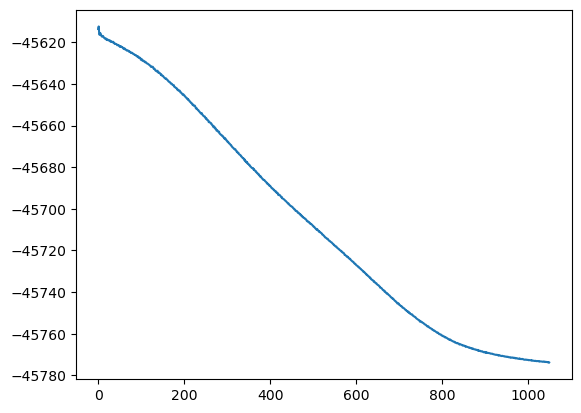

In [22]:
# print("Starting SVI")
# start = time.perf_counter()
# opt = optax.adabelief(1e-4, b1=0.95, b2=0.99)
# qz, loss_hist = model_seq.SVI(best, opt, n_vi=1000, num_steps=1050)
# # jnp.save("svi_samples.npy", np.array(qz.sample(sample_shape=(50000), seed=jax.random.PRNGKey(0))))
# plt.plot(loss_hist)
# jnp.save("loss_hist", loss_hist)
# plt.savefig("svi.png")
# jnp.savez('qz.npz', loc=qz.loc, scale_tril=qz.scale_tril)
# end = time.perf_counter()
# print("SVI time taken: ", (end - start))

In [5]:
map_best = jnp.load('best.npy')

f = jnp.load('qz.npz')
qz = tfd.MultivariateNormalTriL(loc=f['loc'], scale_tril=f['scale_tril'])

# default_start = jnp.diag(jnp.ones((map_best.shape[-1],))) * 1e-3
# no_SVI_qz = tfd.MultivariateNormalTriL(loc=jnp.squeeze(map_best), scale_tril=default_start)
# qz = no_SVI_qz

# half_SVI_qz = tfd.MultivariateNormalTriL(loc=qz.loc,scale_tril=default_start)
# qz = half_SVI_qz
    

# hmc_samples = jnp.load('samples.npy').transpose((1, 2, 0, 3)).reshape(64, 10000, 38)
# hmc_mean = jnp.mean(hmc_samples, axis=(0,1))
# hmc_cov = jnp.cov(hmc_samples.reshape(-1,hmc_samples.shape[-1]).T)
# qz = tfd.MultivariateNormalFullCovariance(loc=hmc_mean, covariance_matrix=hmc_cov)

In [11]:
# import helpers
# importlib.reload(helpers)
# from helpers import *
# mean_x = prob_model.bij.forward(list(qz.loc.T))
# # sim_img = lens_sim.simulate(mean_x)

# fig, axs = plt.subplots(1,4)
# fig.set_size_inches(12,3)

# plot_image_results(fig, axs, jnp.array(observed_img), lens_sim=lens_sim, predicted_params=mean_x, background_rms = 0.007616264, exp_time = 1197.699462)


In [48]:
from tensorflow_probability.substrates.jax import (
    distributions as tfd,
    bijectors as tfb,
    experimental as tfe,
)
from jax import pmap, jit
def HMC_multi(
            self,
            q_z,
            init_eps=0.3,
            init_l=3,
            n_hmc=50,
            num_burnin_steps=250,
            num_results=750,
            max_leapfrog_steps=30,
            seed=0,
    ):
        dev_cnt = len(jax.devices())
        local_dev_cnt = len(jax.local_devices())
        # seeds are per process (node)
        seeds = jax.random.split(jax.random.fold_in(jax.random.PRNGKey(seed), jax.process_index()), local_dev_cnt)
        n_hmc = (n_hmc // dev_cnt) * dev_cnt
        lens_sim = LensSimulator(
            self.phys_model,
            self.sim_config,
            bs=n_hmc // dev_cnt,
        )
        momentum_distribution = tfd.MultivariateNormalFullCovariance(
            loc=jnp.zeros_like(q_z.mean()),
            covariance_matrix=jnp.linalg.inv(q_z.covariance()),
        )

        @jit
        def log_prob(z):
            return self.prob_model.log_prob(lens_sim, z)[0]

        @pmap
        def run_chain(seed):
            start = q_z.sample(n_hmc // dev_cnt, seed=seed)
            num_adaptation_steps = int(num_burnin_steps * 0.8)
            mc_kernel = tfe.mcmc.PreconditionedHamiltonianMonteCarlo(
                target_log_prob_fn=log_prob,
                momentum_distribution=momentum_distribution,
                step_size=init_eps,
                num_leapfrog_steps=init_l,
                store_parameters_in_results=True,
            )

            mc_kernel = tfe.mcmc.GradientBasedTrajectoryLengthAdaptation(
                mc_kernel,
                num_adaptation_steps=num_adaptation_steps,
                max_leapfrog_steps=max_leapfrog_steps,
            )
            mc_kernel = tfp.mcmc.DualAveragingStepSizeAdaptation(
                inner_kernel=mc_kernel, num_adaptation_steps=num_adaptation_steps
            )

            def trace_L(states, previous_kernel_results):
                # return mc_kernel.inner_kernel.num_leapfrog_steps_getter_fn(previous_kernel_results)# previous_kernel_results.num_leapfrog_steps
                return previous_kernel_results.inner_results.inner_results.proposed_results.num_leapfrog_steps

            return tfp.mcmc.sample_chain(
                num_results=num_results,
                num_burnin_steps=num_burnin_steps,
                current_state=start,
                trace_fn=trace_L,#lambda _, pkr: None,
                seed=seed,
                kernel=mc_kernel,
                # return_final_kernel_results=True,
            )

        start = time.time()
        samples = run_chain(seeds)
        end = time.time()
        # aggregate over all devices

        # print(f"LEAPFROG STEPS: {samples.num_leapfrog_steps_getter_fn(samples)}")

        # process_mesh = jax.make_mesh((local_dev_cnt,), ('local_device',))
        # sharding = jax.sharding.NamedSharding(process_mesh, P('local_device', None, None, None)) 
        # print(f'{samples.all_states.shape=}')
        # process_samples = jax.make_array_from_process_local_data(sharding, samples.all_states)
        # print(f'{process_samples.shape=}')
        # all_samples is (num_processes, num_devices_per_process, num_steps, n_hmc_per_device, 22)
        all_samples = jax.experimental.multihost_utils.process_allgather(samples.all_states)
        total_leapfrog_steps = jax.experimental.multihost_utils.process_allgather(samples.trace)
        # print(all_samples.reshape(all_samples.shape[0] * all_samples.shape[1], *all_samples.shape[2:]).shape)
        # reshape to (num_devices, num_steps, n_hmc_per_device, , 22), then swap num_steps, n_hmc_per_device
        device_partitioned_samples = jnp.swapaxes(all_samples.reshape(all_samples.shape[0] * all_samples.shape[1], *all_samples.shape[2:]), 1, 2)
        # chain_partitioned_samples is (num_chains, num_steps, 22)
        # chain_partitioned_samples = device_partitioned_samples.reshape(device_partitioned_samples.shape[0] * device_partitioned_samples.shape[1], *device_partitioned_samples.shape[2:])
        return device_partitioned_samples, total_leapfrog_steps

smp, num_leapfrog = HMC_multi(model_seq, results["SVI"].qz, n_hmc=16)

In [50]:
print("HMC: Total number of leapfrog steps (grad evals) per chain (varies by device):", np.sum(np.squeeze(num_leapfrog), axis=1))

HMC: Total number of leapfrog steps (grad evals) per chain (varies by device): [1505 1505 1483 1498]


In [6]:
def log_prob(z):
    return prob_model.log_prob(lens_sim, z)[0]


inv_mass_mat = qz.covariance()

# inv_mass_mat_true = jnp.cov(hmc_samples.reshape(-1,hmc_samples.shape[-1]).T)

transform = lambda state, info: state.position


2026-04-21 16:11:22.242682: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.


In [7]:

n_grad_per_integration_step_mclachlan = len(mclachlan_coefficients)//2 #* Happens on every odd step of the integrator

integrator = isokinetic_mclachlan_smart

 # build the kernel
kernel = lambda inverse_mass_matrix : blackjax.mcmc.mclmc.build_kernel(
    logdensity_fn=log_prob,
    integrator=integrator,
    inverse_mass_matrix=inverse_mass_matrix,
)

dim = map_best.shape[-1]
print("Dimension:",dim)

desired_energy_variance= 5e-4

Dimension: 38


In [10]:
importlib.reload(mclmc_alt)
from mclmc_alt import mclmc_find_L_and_step_size_smart
rng_key = jax.random.key(0)
init_key, tune_key, run_key = jax.random.split(rng_key, 3)

start_loc = jnp.squeeze(qz.sample(1, seed=init_key))

initial_state = blackjax.mcmc.mclmc.init(
    position=start_loc, logdensity_fn=log_prob, rng_key=init_key
)

starting_adapt_state = blackjax.adaptation.mclmc_adaptation.MCLMCAdaptationState(
    jnp.sqrt(dim), jnp.sqrt(dim) * 0.25, inverse_mass_matrix=inv_mass_mat
)

starttime = time.perf_counter()
(
    blackjax_state_after_tuning,
    blackjax_mclmc_sampler_params,
    _
) = mclmc_find_L_and_step_size_smart(
    mclmc_kernel=kernel,
    num_steps=10000,
    state=initial_state,
    rng_key=tune_key,
    frac_tune1=0.1, #* initial step size tuning
    frac_tune2=0.5, #* Used for mass matrix adaptation
    frac_tune3=0.5, #! Tuning L. ~10 effective samples are needed for this to be accurate
    params=starting_adapt_state,
    desired_energy_var=desired_energy_variance,
    multi_chain=False,
    mass_matrix_adapt=False,
)
total_time = time.perf_counter()-starttime
print("Burnin Time:", total_time)

Stage 3 ESS Mean: 3.3603179454803467, Min: 1.0004003047943115, Max: 5.510982036590576
L Before Final Update: 6.164414
Burnin Time: 154.71712201903574


In [11]:
L = blackjax_mclmc_sampler_params.L
step_size = blackjax_mclmc_sampler_params.step_size
print(f"ADAPTED. L: {L}, step_size: {step_size}, L/step: {L/step_size}")
if jnp.any(jnp.isnan(blackjax_mclmc_sampler_params.inverse_mass_matrix)):
    raise ValueError("Inverse Mass Matrix Has NaNs!!!")
if jnp.any(jnp.real(jnp.linalg.eig(blackjax_mclmc_sampler_params.inverse_mass_matrix)[0])<0):
    raise ValueError("Inverse Mass Matrix Has Negative Eigenvalues!!!")

ADAPTED. L: 0.8974984884262085, step_size: 0.0015079401200637221, L/step: 595.1817626953125


In [14]:
L_mod = 5
step_mod = 1000
print(f"MODIFIED. L: {L*L_mod}, step_size: {step_size*step_mod}, L/step: {L*L_mod/(step_size*step_mod)}")
sampling_alg = blackjax.mclmc(
    log_prob,
    L=L*L_mod,
    step_size=step_size*step_mod,
    inverse_mass_matrix=blackjax_mclmc_sampler_params.inverse_mass_matrix,
    integrator=integrator,
)

starttime = time.perf_counter()
_, single_chain_samples = blackjax.util.run_inference_algorithm(
    rng_key=run_key,
    initial_state=blackjax_state_after_tuning,
    inference_algorithm=sampling_alg,
    num_steps=10000,
    transform=transform,
    progress_bar=True,
)

total_time = time.perf_counter()-starttime
print(f"Sampling took {total_time} s")


MODIFIED. L: 4.487492561340332, step_size: 1.5079401731491089, L/step: 2.9759087562561035


Sampling took 95.99487185198814 s


In [15]:
n_grad_evals_mclmc = single_chain_samples.shape[0]
ESS_mclmc = blackjax.diagnostics.effective_sample_size(single_chain_samples[np.newaxis, :,:], chain_axis=0, sample_axis=1)

print(ESS_mclmc)
print(np.mean(ESS_mclmc)/n_grad_evals_mclmc, " | ", jnp.min(ESS_mclmc)/n_grad_evals_mclmc)

[ 558.44806   450.87256    67.78037    54.031246   31.453062   70.306
   44.44253    54.81914   231.55533  1026.8744    828.0543    486.7939
  490.50507    60.078526  275.386     105.567955  147.00174   453.18585
  388.3521    350.44745   359.18127   812.7689    829.962     366.08163
  328.50186   451.6402     77.98134    35.514584  439.77258   105.78369
  205.00455   532.2143     81.6655     31.73905    63.213463  354.71997
  368.0566    108.656364]
0.030864246  |  0.0031453064


In [113]:
from blackjax.adaptation.mass_matrix import welford_algorithm, WelfordAlgorithmState
from blackjax.adaptation.mclmc_adaptation import pytree_size, MCLMCAdaptationState, handle_nans, incremental_value_update
from blackjax.mcmc.integrators import generalized_two_stage_integrator, format_isokinetic_state_output, ravel_pytree, _normalized_flatten_array
from collections import namedtuple#NamedTuple


def make_L_step_size_adaptation_test(
    kernel,
    dim,
    desired_energy_var=1e-3,
    trust_in_estimate=1.5,
    num_effective_samples=150,
    multi_chain=True,
    num_chains=8,
    mass_matrix_adapt=True,
    continuous_adaptation=False,
):
    """Adapts the stepsize and L of the MCLMC kernel. Designed for unadjusted MCLMC"""

    decay_rate = (num_effective_samples - 1.0) / (num_effective_samples + 1.0)

    welford_init, welford_update, welford_cov = welford_algorithm(is_diagonal_matrix=False)
    def predictor(previous_state, params, adaptive_state, rng_key):
        """does one step with the dynamics and updates the prediction for the optimal stepsize
        Designed for the unadjusted MCHMC"""

        time, x_average, step_size_max = adaptive_state

        rng_key, nan_key = jax.random.split(rng_key)

        # dynamics
        next_state, info = kernel(params.inverse_mass_matrix)(
            rng_key=rng_key,
            state=previous_state,
            L=params.L,
            step_size=params.step_size,
        )

        # step updating
        success, state, step_size_max, energy_change = handle_nans(
            previous_state,
            next_state,
            params.step_size,
            step_size_max,
            info.energy_change,
            nan_key,
        )

        # Warning: var = 0 if there were nans, but we will give it a very small weight
        xi = (
            jnp.square(energy_change) / (dim * desired_energy_var) #* Term in the sum
        ) + 1e-8  # 1e-8 is added to avoid divergences in log xi
        weight = jnp.exp(
            -0.5 * jnp.square(jnp.log(xi) / (6.0 * trust_in_estimate))
        )  # the weight reduces the impact of stepsizes which are much larger on much smaller than the desired one.

        x_average = decay_rate * x_average + weight * (
            xi / jnp.power(params.step_size, 6.0)
        )
        time = decay_rate * time + weight
        step_size = jnp.power(
            x_average / time, -1.0 / 6.0
        )  # We use the Var[E] = O(eps^6) relation here.
        step_size = (step_size < step_size_max) * step_size + (
            step_size > step_size_max
        ) * step_size_max  # if the proposed stepsize is above the stepsize where we have seen divergences
        params_new = params._replace(step_size=step_size)

        adaptive_state = (time, x_average, step_size_max)

        return state, params_new, adaptive_state, success, (xi, weight)

    def predictor_psmile(previous_state, params, adaptive_state, rng_key):
        """
        Does one step with the dynamics and updates the prediction for the optimal stepsize.
        Designed for the unadjusted MCHMC using the pSMILE energy-variance tuner.
        """
        # Unpack the new pSMILE adaptive state
        mu, sigma2, count, step_size_max = adaptive_state
    
        rng_key, nan_key = jax.random.split(rng_key)
    
        # Dynamics
        next_state, info = kernel(params.inverse_mass_matrix)(
            rng_key=rng_key,
            state=previous_state,
            L=params.L,
            step_size=params.step_size,
        )
    
        # Step updating and NaN handling
        success, state, step_size_max, energy_change = handle_nans(
            previous_state,
            next_state,
            params.step_size,
            step_size_max,
            info.energy_change,
            nan_key,
        )

        xi = (
            jnp.square(energy_change) / (dim * desired_energy_var) #* Term in the sum
        ) + 1e-8  # 1e-8 is added to avoid divergences in log xi
    
        # --- pSMILE Adaptation Logic ---
        # Default parameters from Section 4.2 of the SMILE paper
        beta = 1-decay_rate#0.01          # EMA smoothing factor
        delta = 0.1 #0.02         # Step size multiplier
        alpha_param = 0.4 #0.1    # Adaptation probability parameter
        eps = 1e-8           # Small constant to prevent division by zero
        
        abs_dE = jnp.abs(energy_change)
        count = count + 1
    
        # 1. Exponential Moving Averages (Eq. 3)
        mu_next = (1.0 - beta) * mu + beta * abs_dE
        sigma2_next = (1.0 - beta) * sigma2 + beta * jnp.square(abs_dE - mu_next)
    
        # Bias correction for the variance estimate in early tuning stages
        bias_correction = 1.0 - jnp.power(1.0 - beta, count)
        mu_hat = mu_next / bias_correction
        sigma2_hat = sigma2_next / bias_correction
    
        # 2. Gamma Distribution Moment Matching (Eq. 4)
        shape = jnp.square(mu_hat) / (sigma2_hat + eps)
        scale = sigma2_hat / (mu_hat + eps)
    
        # 3. Wilson-Hilferty Transform for Quantiles (Appendix F.4)
        def gamma_quantile(p_val):
            z_p = norm.ppf(p_val)
            term = 1.0 / (9.0 * shape + eps)
            bracket = 1.0 - term + z_p * jnp.sqrt(term)
            return scale * shape * jnp.power(jnp.maximum(bracket, 0.0), 3)
    
        # Calculate tuning thresholds
        tau_lo = gamma_quantile(alpha_param / 2.0)#(alpha_param / 3.0)
        tau_hi = gamma_quantile(1.0-alpha_param / 2.0)#(1.0 - 2.0 * alpha_param / 3.0)
        tau_guardrail = gamma_quantile(0.98) # Guardrail threshold (Eq. 5)
    
        # 4. Adaptive Step Size Multiplier (Eq. 6)
        current_eta = params.step_size
        step_size = jnp.where(
            abs_dE < tau_lo,
            current_eta * (1.0 + delta),
            jnp.where(
                abs_dE > tau_hi,
                current_eta * (1.0 - delta),
                current_eta
            )
        )
        
        # Prevent step size from exceeding the historical divergence threshold
        step_size = jnp.minimum(step_size, step_size_max)
    
        params_new = params._replace(step_size=step_size)
        
        # Repack the updated adaptive state
        adaptive_state_new = (mu_next, sigma2_next, count, step_size_max)
    
        return state, params_new, adaptive_state_new, success, (xi, 0)

    def predictor_psmile_cont(previous_state, params, adaptive_state, rng_key):
        """
        Does one step with the dynamics and updates the prediction for the optimal stepsize.
        Designed for the unadjusted MCHMC using the pSMILE energy-variance tuner.
        """
        # Unpack the new pSMILE adaptive state
        mu, sigma2, count, step_size_max = adaptive_state
    
        rng_key, nan_key = jax.random.split(rng_key)
    
        # Dynamics
        next_state, info = kernel(params.inverse_mass_matrix)(
            rng_key=rng_key,
            state=previous_state,
            L=params.L,
            step_size=params.step_size,
        )
    
        # Step updating and NaN handling
        success, state, step_size_max, energy_change = handle_nans(
            previous_state,
            next_state,
            params.step_size,
            step_size_max,
            info.energy_change,
            nan_key,
        )

        xi = (
            jnp.square(energy_change) / (dim * desired_energy_var) #* Term in the sum
        ) + 1e-8  # 1e-8 is added to avoid divergences in log xi
    
        # --- pSMILE Adaptation Logic ---
        # Default parameters from Section 4.2 of the SMILE paper
        beta = 1-decay_rate#0.01          # EMA smoothing factor
        delta = 0.1 #0.02         # Step size multiplier
        # alpha_param = 0.4 #0.1    # Adaptation probability parameter
        eps = 1e-8           # Small constant to prevent division by zero
        
        abs_dE = jnp.abs(energy_change)
        count = count + 1
    
        # 1. Exponential Moving Averages (Eq. 3)
        mu_next = (1.0 - beta) * mu + beta * abs_dE
        sigma2_next = (1.0 - beta) * sigma2 + beta * jnp.square(abs_dE - mu_next)
    
        # Bias correction for the variance estimate in early tuning stages
        bias_correction = 1.0 - jnp.power(1.0 - beta, count)
        mu_hat = mu_next / bias_correction
        sigma2_hat = sigma2_next / bias_correction
    
        # 2. Gamma Distribution Moment Matching (Eq. 4)
        shape = jnp.square(mu_hat) / (sigma2_hat + eps)
        scale = sigma2_hat / (mu_hat + eps)
    
        # # 3. Wilson-Hilferty Transform for Quantiles (Appendix F.4)
        # def gamma_quantile(p_val):
        #     z_p = norm.ppf(p_val)
        #     term = 1.0 / (9.0 * shape + eps)
        #     bracket = 1.0 - term + z_p * jnp.sqrt(term)
        #     return scale * shape * jnp.power(jnp.maximum(bracket, 0.0), 3)
    
        # # Calculate tuning thresholds
        # tau_lo = gamma_quantile(alpha_param / 2.0)#(alpha_param / 3.0)
        # tau_hi = gamma_quantile(1.0-alpha_param / 2.0)#(1.0 - 2.0 * alpha_param / 3.0)
        # tau_guardrail = gamma_quantile(0.98) # Guardrail threshold (Eq. 5)
    
        # # 4. Adaptive Step Size Multiplier (Eq. 6)
        # current_eta = params.step_size
        # step_size = jnp.where(
        #     abs_dE < tau_lo,
        #     current_eta * (1.0 + delta),
        #     jnp.where(
        #         abs_dE > tau_hi,
        #         current_eta * (1.0 - delta),
        #         current_eta
        #     )
        # )
        cdf_value = jax.scipy.stats.gamma.cdf(abs_dE, shape, loc=0.0, scale=scale)
        #* If cdf_value>0.5, lower the step size, if less, raise it
        adjustment = (0.5-cdf_value)*delta
        step_size = params.step_size * (1+adjustment)
        
        # Prevent step size from exceeding the historical divergence threshold
        step_size = jnp.minimum(step_size, step_size_max)
    
        params_new = params._replace(step_size=step_size)
        
        # Repack the updated adaptive state
        adaptive_state_new = (mu_next, sigma2_next, count, step_size_max)
    
        return state, params_new, adaptive_state_new, success, (xi, 0)

    Hist = namedtuple("hist", ["pos", "step_size", "x_average", "xi", "step_size_max", "weight", "time", "nonan"])
    def step(iteration_state, weight_and_key):
        """does one step of the dynamics and updates the estimate of the optimal step size, tracking updates to the covariance"""

        mask, rng_key, svi_inverse_mass_matrix = weight_and_key
        state, params, adaptive_state, welford_state = iteration_state

        state, params, adaptive_state, success, diagnostics = predictor_psmile_cont(
            state, params, adaptive_state, rng_key
        )

        x = ravel_pytree(state.position)[0]

        #! Choose how to update mass matrix, right now just tracking
        welford_state = jax.lax.cond(mask, 
            welford_update,
            lambda welford_state, x : welford_state,
            welford_state, x
        )
        xi = diagnostics[0]
        weight = diagnostics[1]
        h = Hist(pos = state.position, step_size= params.step_size, x_average=adaptive_state[1], 
                 xi=xi, step_size_max=adaptive_state[2], weight=weight, time=adaptive_state[0], nonan=success)
        return (state, params, adaptive_state, welford_state), h
        

    def L_step_size_adaptation(state, params, num_steps1, rng_key):

        welford_start = welford_init(state.position.shape[-1])

        step_func = step_continuous_mass_matrix_adapt if continuous_adaptation else step
        if continuous_adaptation:
            print("USING CONTINUOUS MASS MATRIX ADAPTATION. This is mostly untested. Could screw up")
        run_steps = lambda xs, state, params: jax.lax.scan(
            step_func,
            init=(
                state,
                params,
                (jnp.array(0.0), jnp.array(0.0), jnp.array(0, dtype=jnp.int32), jnp.inf),#(0.0, 0.0, jnp.inf),
                welford_start,
            ),
            xs=xs,
        )

        # we use the last num_steps2 to compute the diagonal preconditioner
        mask = jnp.zeros(num_steps1)
        num_steps_net = num_steps1

        inverse_mass_matrix_tiled = jnp.tile(params.inverse_mass_matrix, (num_steps1, 1, 1))
        
        # run the steps
        if multi_chain:
            run_key, final_key = jax.random.split(rng_key, 2)
            L_step_size_adaptation_keys = jax.random.split(run_key, (num_chains, num_steps1))

            run_steps = jax.jit(jax.vmap(run_steps, in_axes=((None, 0, None), 0, None), axis_name='chain'))
        else:
            #* Original behavior for only one chain
            L_step_size_adaptation_keys = jax.random.split(
                rng_key, num_steps1 + 1
            )
            L_step_size_adaptation_keys, final_key = (
                L_step_size_adaptation_keys[:-1],
                L_step_size_adaptation_keys[-1],
            )

        carry, hist = run_steps(
            (mask, L_step_size_adaptation_keys, inverse_mass_matrix_tiled), state, params
        )
        state, params, _, welford_state = carry

        return state, params, hist
    return L_step_size_adaptation

In [94]:
rng_key = jax.random.key(0)
init_key, tune_key, run_key = jax.random.split(rng_key, 3)
start_loc = jnp.squeeze(qz.sample(1, seed=init_key))

initial_state = blackjax.mcmc.mclmc.init(
    position=start_loc, logdensity_fn=log_prob, rng_key=init_key
)

starting_adapt_state = blackjax.adaptation.mclmc_adaptation.MCLMCAdaptationState(
    jnp.sqrt(dim), jnp.sqrt(dim) * 0.25, inverse_mass_matrix=inv_mass_mat
)

def make_demo_kernel():
    prior = make_default_prior()
    gigal_dir = os.path.join(home,'gigalens/src/gigalens/')
    kernel = np.load(gigal_dir + '/assets/psf.npy').astype(np.float32)
    sim_config = SimulatorConfig(delta_pix=0.065, num_pix=60, supersample=2, kernel=kernel)
    phys_model = PhysicalModel([epl.EPL(50), shear.Shear()], [sersic.SersicEllipse(use_lstsq=False)], [sersic.SersicEllipse(use_lstsq=False)])
    lens_sim = LensSimulator(phys_model, sim_config, bs=1)
    observed_img = np.load(gigal_dir + '/assets/demo.npy')
    prob_model = ForwardProbModel(prior, observed_img, background_rms=0.2, exp_time=100)
    model_seq = ModellingSequence(phys_model, prob_model, sim_config)
    
    results = {}
    results["MAP"] = MAPResults.load(os.path.join(home, "GIGALens-Code/alternate_inference/test_system"), model_seq)
    results["SVI"] = SVIResults.load(os.path.join(home, "GIGALens-Code/alternate_inference/test_system"), model_seq)
    
    def log_prob(z):
        return prob_model.log_prob(lens_sim, z)[0]
    
    inv_mass_mat = results['SVI'].qz.covariance()
    
    # inv_mass_mat_true = jnp.cov(results['HMC'].HMC_samples_z.reshape(-1, 22).T)
    
    transform = lambda state, info: state.position
    
    kernel = lambda inverse_mass_matrix : blackjax.mcmc.mclmc.build_kernel(
        logdensity_fn=log_prob,
        integrator=integrator,
        inverse_mass_matrix=inverse_mass_matrix,
    )

    start_loc = jnp.squeeze(results['SVI'].qz.sample(1, seed=init_key))

    initial_state = blackjax.mcmc.mclmc.init(
        position=start_loc, logdensity_fn=log_prob, rng_key=init_key
    )
    
    starting_adapt_state = blackjax.adaptation.mclmc_adaptation.MCLMCAdaptationState(
        jnp.sqrt(dim), jnp.sqrt(dim) * 0.25, inverse_mass_matrix=inv_mass_mat
    )
    return kernel, initial_state, starting_adapt_state

kernel_demo, initial_state_demo, starting_adapt_state_demo = make_demo_kernel()

In [114]:
desired_E_var = 5e-4
starttime = time.perf_counter()
state, params, hist_demo = make_L_step_size_adaptation_test(
        kernel=kernel_demo,
        dim=22,
        desired_energy_var=desired_E_var,
        trust_in_estimate=1.5,
        num_effective_samples=100,
        multi_chain=False,
        # num_chains=num_chains,
        mass_matrix_adapt=False,
        continuous_adaptation=False,
    )(initial_state_demo, starting_adapt_state_demo._replace(step_size=4), 1000, tune_key) #._replace(step_size=jnp.sqrt(22))
print(f"Total time: {time.perf_counter()-starttime}")

starttime = time.perf_counter()
state, params, hist_238 = make_L_step_size_adaptation_test(
        kernel=kernel,
        dim=dim,
        desired_energy_var=desired_E_var,
        trust_in_estimate=1.5,
        num_effective_samples=100,
        multi_chain=False,
        # num_chains=num_chains,
        mass_matrix_adapt=False,
        continuous_adaptation=False,
    )(initial_state, starting_adapt_state._replace(step_size=4), 1000, tune_key) #._replace(inverse_mass_matrix=blackjax_mclmc_sampler_params.inverse_mass_matrix)
print(f"Total time: {time.perf_counter()-starttime}")

Total time: 14.587719469040167
Total time: 27.392536188010126


0.21419884
8.447862


/tmp/ipykernel_1303666/2715253096.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


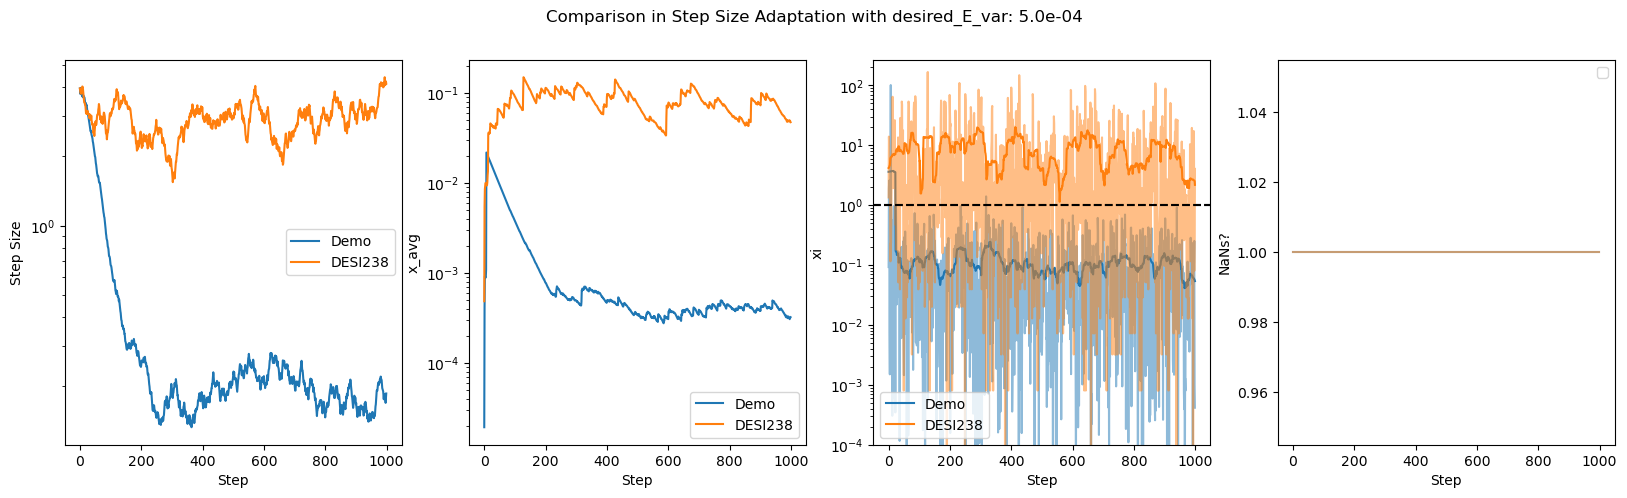

In [115]:
fig, axs = plt.subplots(1,4, sharex=True)
fig.set_size_inches(20, 5)

def diagnost_plot(h, axs, label='', color=''):
    ax1, ax2, ax3, ax4 = axs
    x = np.arange(0, h.step_size.shape[0])
    ax1.plot(x, h.step_size, label=label, color=color)
    ax1.set_yscale('log')
    ax1.set_ylabel("Step Size")
    
    ax2.plot(h.x_average, label=label, color=color)
    ax2.set_yscale('log')
    ax2.set_ylabel("x_avg")

    smooth_kernel_size = 30
    kernel = np.ones(smooth_kernel_size) / smooth_kernel_size
    xi_smoothed = np.convolve(h.xi, kernel, mode='same')
    
    ax3.plot(h.xi, alpha=0.5, color=color)
    ax3.plot(xi_smoothed, label=label, alpha=1.0, color=color)
    ax3.axhline(1.0, color='black', linestyle='--')
    ax3.set_yscale('log')
    ax3.set_ylim(bottom=1e-4)
    ax3.set_ylabel('xi')

    # xi_weight = h.xi * h.weight/np.pow(step_size, 6)
    # xi_weight_smoothed = np.convolve(xi_weight, kernel, mode='same')
    ax4.plot(h.nonan, alpha=0.5, color=color)
    # ax4.plot(xi_weight_smoothed, label=label, alpha=1.0, color=color)
    # ax4.set_yscale('log')
    ax4.set_ylabel('NaNs?')
    # if jnp.any(h.
    print(jnp.mean(h.xi))
    

diagnost_plot(hist_demo, axs, label='Demo', color='C0')
diagnost_plot(hist_238, axs, label='DESI238', color='C1')

for ax in axs:
    ax.set_xlabel("Step")
    ax.legend()
plt.suptitle(f"Comparison in Step Size Adaptation with desired_E_var: {desired_E_var:.1e}")
plt.show()

In [37]:
# importlib.reload(mclmc_alt)
# from mclmc_alt import mclmc_find_L_and_step_size_smart
# rng_key = jax.random.key(0)
# init_key, tune_key, run_key = jax.random.split(rng_key, 3)

# n_chains = 16
# state_multi = init_multi(qz.sample((n_chains,), seed=init_key), init_key, log_prob)

# starting_adapt_state = blackjax.adaptation.mclmc_adaptation.MCLMCAdaptationState(
#     jnp.sqrt(dim), jnp.sqrt(dim) * 0.25, inverse_mass_matrix=inv_mass_mat
# )

# starttime = time.perf_counter()
# # find values for L and step_size
# (
#     blackjax_state_after_tuning,
#     blackjax_mclmc_sampler_params,
#     _
# ) = mclmc_find_L_and_step_size_smart(
#     mclmc_kernel=kernel,
#     num_steps=2000,
#     state=state_multi,
#     rng_key=tune_key,
#     frac_tune1=0.2, #* initial step size tuning
#     frac_tune2=0.6, #* Used for mass matrix adaptation
#     frac_tune3=0.2, #! Tuning L. ~10 effective samples are needed for this to be accurate
#     params=starting_adapt_state,
#     desired_energy_var=5e-2,#desired_energy_variance,
#     multi_chain=True,
#     num_chains=n_chains,
#     mass_matrix_adapt=True,
#     continuous_adaptation=True,
# )

# total_time = time.perf_counter()-starttime
# print("Burnin Time:", total_time)

2026-03-08 11:57:38.994253: E external/xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng35{k2=1,k5=3,k14=2} for conv %cudnn-conv.2 = (f32[16,5,240,240]{3,2,1,0}, u8[0]{0}) custom-call(%bitcast.691, %constant.1007), window={size=53x53 pad=26_26x26_26}, dim_labels=bf01_oi01->bf01, feature_group_count=5, custom_call_target="__cudnn$convForward", metadata={op_name="jit(<lambda>)/jit(main)/vmap(jvp(jit(log_prob)))/jit(lstsq_simulate)/conv_general_dilated" source_file="/global/homes/l/linusu//gigalens/src/gigalens/jax/simulator.py" source_line=116}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-03-08 11:57:40.002609: E external/xla/xla/service/slow_operation_alarm.cc:140] The operation took 2.008450585s
Trying algorithm eng35{k2=1,k5=3,k14=2} for conv %cud

USING CONTINUOUS MASS MATRIX ADAPTATION. This is mostly untested. Could screw up


2026-03-08 11:57:55.026942: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.


[4.799465  4.543724  4.3178816 3.1490974 3.9218073 4.555199  4.8749127
 3.9632754 3.919464  4.2411766 4.0935917 3.5656247 4.8005247 4.8789096
 4.0872984 4.2908144]
Stage 2 Welford Cov Egval Mean: (0.01941496692597866+0j), Min: (1.1128099686175119e-07+0j), Max: (0.6054643392562866+0j)
Stage 2 Cov Egval Mean: (0.01950874924659729+0j), Min: (1.1121002074787611e-07+0j), Max: (0.6085307002067566+0j)
Stage 2 Step Size: 4.2501726150512695, L: 6.164413928985596
Burnin Time: 196.27704796701437


In [38]:
L = blackjax_mclmc_sampler_params.L
step_size = blackjax_mclmc_sampler_params.step_size
print(f"ADAPTED. L: {L}, step_size: {step_size}, L/step: {L/step_size}")

ADAPTED. L: 51.89522933959961, step_size: 4.078725814819336, L/step: 12.723392486572266


In [16]:
# # L_set = 6.0
# # step_size_set = 1.0
# # print(f"MODIFIED. L: {L_set}, step_size: {step_size_set}, L/step: {L_set/step_size_set}")
# sampling_alg = mclmc_multi(
#     log_prob,
#     L=L,
#     step_size=step_size,
#     num_chains=n_chains,
#     inverse_mass_matrix=blackjax_mclmc_sampler_params.inverse_mass_matrix,
#     integrator=integrator,
# )

# transform_with_lp = lambda state, info: (state.position, state.logdensity)

# starttime = time.perf_counter()
# _, hist = blackjax.util.run_inference_algorithm(
#     rng_key=run_key,
#     initial_state=blackjax_state_after_tuning,
#     inference_algorithm=sampling_alg,
#     num_steps=2000,
#     transform=transform_with_lp,
#     progress_bar=True,
# )
# multi_chain_samples, lps = hist
# multi_chain_samples = jnp.transpose(multi_chain_samples, axes=(1, 0, 2))

# total_time = time.perf_counter()-starttime
# print(f"Sampling took {total_time} s")


2026-03-03 08:33:15.370204: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.


Sampling took 67.66326537699206 s


In [17]:
print(multi_chain_samples.shape)

(16, 2000, 43)


In [15]:
import alternate_inference.mclmc_alt
importlib.reload(alternate_inference.mclmc_alt)
from alternate_inference.mclmc_alt import MCLMC_JIT, isokinetic_velocity_verlet_smart

num_burnin_steps = 2000
num_results=2000
frac_tune1=0.2 #* initial step size tuning
frac_tune2=0.6 #* Used for mass matrix adaptation
frac_tune3=0.2 #! Tuning L. ~10 effective samples are needed for this to be accurate

debug_hist = MCLMC_JIT(
    model_seq, qz, 
    n_hmc=8, num_burnin_steps=num_burnin_steps, num_results=num_results, 
    desired_energy_variance=5e-4, frac_tune1=frac_tune1, frac_tune2=frac_tune2, frac_tune3=frac_tune3,
    seed=0, debug_output=True, step_size_adapt_use_psmile=False, use_shard_map=True,progress_bar=True,
    # integrator=isokinetic_velocity_verlet_smart
)
mclmc_samples = debug_hist.position[:, -num_results:, :]

Sampling took 72.2942555489717 s


In [16]:
multi_chain_samples = mclmc_samples

3.1993904


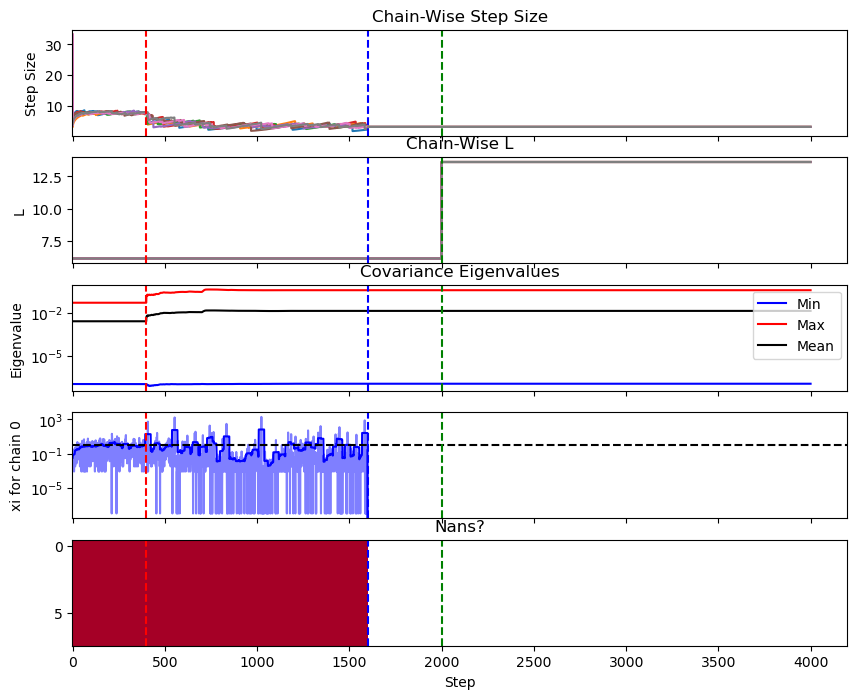

In [17]:
print(debug_hist.step_size[0, -1])
stage1 = int(frac_tune1*num_burnin_steps)
stage2 = int((frac_tune1+frac_tune2)*num_burnin_steps)
stage3 = int((frac_tune1+frac_tune2+frac_tune3)*num_burnin_steps)

fig, axs = plt.subplots(5, 1, sharex=True)
ax1, ax2, ax3, ax4, ax_last =axs
fig.set_size_inches(10, 8)
ax1.plot(debug_hist.step_size.T)
ax1.set_title("Chain-Wise Step Size")
ax1.set_ylabel("Step Size")
# ax1.set_ylim(top=10)
# ax1.set_yscale('log')

ax2.plot(debug_hist.L.T)
ax2.set_title("Chain-Wise L")
ax2.set_ylabel("L")
# ax2.set_ylim(top=20)



inverse_mass_matrix_hist = debug_hist.inverse_mass_matrix[0]
vmapped_eigval = jax.vmap(lambda x: jnp.linalg.eig(x)[0])
mass_mat_eigval = vmapped_eigval(inverse_mass_matrix_hist)
min_eigval = jnp.min(mass_mat_eigval, axis=1)
max_eigval = jnp.max(mass_mat_eigval, axis=1)
mean_eigval = jnp.mean(mass_mat_eigval, axis=1)

ax3.plot(min_eigval, label='Min', color='blue')
ax3.plot(max_eigval, label='Max', color='red')
ax3.plot(mean_eigval, label='Mean', color='black')
ax3.legend()
ax3.set_title("Covariance Eigenvalues")
ax3.set_yscale('log')
ax3.set_ylabel("Eigenvalue")



smooth_kernel_size = 30
kernel = np.ones(smooth_kernel_size) / smooth_kernel_size
xi_chain = debug_hist.xi[8]
xi_smoothed = np.convolve(xi_chain, kernel, mode='same')
ax4.plot(xi_chain, alpha=0.5, color='blue')
ax4.plot(xi_smoothed, alpha=1.0, color='blue')
ax4.set_yscale('log')
ax4.set_ylabel("xi for chain 0")
ax4.axhline(1.0, color='black', linestyle='--')

ax_last.set_xlabel("Step")

ax_last.set_title("Nans?")
ax_last.imshow(debug_hist.nonan[:,:stage2], aspect='auto', interpolation='none', cmap='RdYlGn')

for ax in axs:
    ax.axvline(stage1, color='red', linestyle='--')
    ax.axvline(stage2, color='blue', linestyle='--')
    ax.axvline(stage3, color='green', linestyle='--')

    # ax.set_xlim(right=stage3)


plt.show()

In [18]:
print(params.step_size)
print(params.L)

NameError: name 'params' is not defined

In [19]:
# n_grad_evals_mclmc = num_steps
n_grad_evals_mclmc = multi_chain_samples.shape[0]*multi_chain_samples.shape[1]
# ESS_mclmc = blackjax.diagnostics.effective_sample_size(samples_mclmc[np.newaxis, :,:], chain_axis=0, sample_axis=1)
ESS_mclmc = blackjax.diagnostics.effective_sample_size(multi_chain_samples, chain_axis=0, sample_axis=1)

print(ESS_mclmc)
print(np.mean(ESS_mclmc)/n_grad_evals_mclmc, " | ", jnp.min(ESS_mclmc)/n_grad_evals_mclmc)

[3600.0227 3671.3013 3684.4927 3799.5322 3639.451  3711.5693 3636.337
 3781.3137 3656.3706 3894.1448 3812.9302 3681.6772 3740.4553 3614.931
 3788.0942 3697.7517 3701.3914 3791.1892 3748.6453 3753.292  3714.1094
 3768.8674 3786.8562 3749.02   3727.2979 3745.732  3697.2356 3633.4983
 3743.6458 3739.967  3742.6123 3721.143  3300.4375 3640.512  3660.3352
 3615.4934 3726.6797 1691.9463]
0.2283064  |  0.10574665


In [20]:
rhat = blackjax.diagnostics.potential_scale_reduction(multi_chain_samples, chain_axis=0, sample_axis=1)
print(rhat)
print(jnp.max(rhat))

[1.0007563  1.0002884  1.0003313  1.00014    1.0004938  1.0006336
 1.0004075  1.0000578  1.0001421  1.0001137  0.9999228  1.0000601
 1.000403   1.0002906  1.0002673  1.000197   0.99984545 1.0005152
 1.0002444  1.0000365  1.0003183  1.0005662  0.9999911  1.000006
 1.0000285  1.0002803  1.0005038  1.000386   1.0005121  1.0003439
 0.9999559  1.0002896  1.0012275  1.0004494  1.0006591  1.0003213
 1.0002794  1.0024238 ]
1.0024238


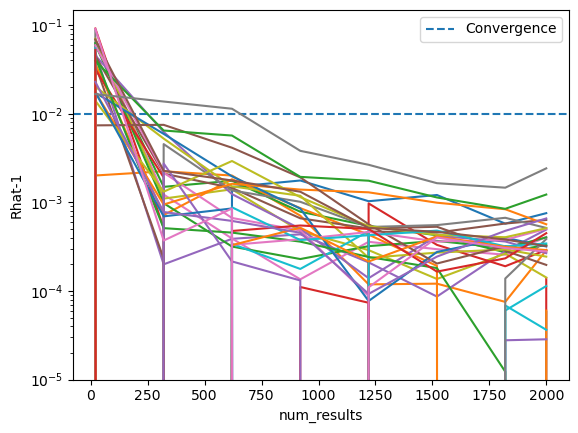

In [21]:

sample_length = list(range(20, multi_chain_samples.shape[1], 300)) + [multi_chain_samples.shape[1]]
rhats = -np.ones((len(sample_length), multi_chain_samples.shape[-1]))
for i, l in enumerate(sample_length):
    rhats[i] = blackjax.diagnostics.potential_scale_reduction(multi_chain_samples[:, :l, :], chain_axis=0, sample_axis=1)
plt.axhline(1e-2, linestyle='--', label='Convergence')
plt.plot(sample_length, rhats-1)
plt.yscale('log')
plt.ylabel("Rhat-1")
plt.xlabel("num_results")
plt.legend()
plt.ylim(bottom=1e-5)
plt.show()

In [14]:
nan_chain_idx = jnp.unique(jnp.where(jnp.isnan(multi_chain_samples))[0])[2]
print(f"Using chain {nan_chain_idx}")
nan_chain = multi_chain_samples[nan_chain_idx]
nan_step1 = jnp.unique(jnp.where(jnp.isnan(nan_chain))[0])[0]
print(f"NaN Starts at step {nan_step1}")

Using chain 2
NaN Starts at step 591


In [15]:
nan_chain = multi_chain_samples[nan_chain_idx]
pre_post_nan_step = nan_chain[nan_step1-2:nan_step1+1]
# lp_mapped = jax.vmap(log_prob)
lp_and_grad_mapped = jax.vmap(jax.value_and_grad(log_prob))
print(pre_post_nan_step)
print(lp_and_grad_mapped(pre_post_nan_step))
nan_lp_point = nan_chain[nan_step1-1] #* Has finite positions but NaN log prob

[[-1.27949581e-01 -1.29032314e-01  1.94046676e-01  1.25981316e-01
  -3.88392359e-01  3.87221724e-01  1.49740323e-01 -1.56612191e-02
  -2.29051566e+00 -3.31589270e+00 -3.08701468e+00 -6.01813376e-01
   1.43016028e+00  5.12323797e-01  5.87068677e-01 -1.06152162e-01
  -1.25475600e-01 -6.24795079e-01  8.19044769e-01 -2.47447896e+00
  -1.32167482e+00 -1.19868778e-01 -1.22556299e-01  3.05576343e-02
  -3.66115153e-01 -1.36579537e+00 -1.44216669e+00  2.97709573e-02
  -1.40639976e-01 -2.55659372e-01  7.04677045e-01 -2.44605398e+00
  -2.60928464e+00  2.93597221e-01  5.04490174e-03  1.56388462e+00
  -6.01360917e-01 -5.68715954e+00]
 [-1.27785534e-01 -1.28372088e-01  1.91397175e-01  1.23467065e-01
  -3.92267287e-01  3.86947572e-01  1.49699882e-01 -1.55916950e-02
  -2.29000258e+00 -3.31577420e+00 -3.08714604e+00 -6.02452040e-01
   1.43426645e+00  5.48478246e-01  5.84933460e-01 -1.05166323e-01
  -1.24891654e-01 -6.21062458e-01  8.12790215e-01 -2.46084142e+00
  -1.32840335e+00 -1.20020799e-01 -1.2259

In [26]:
# import numpy as np
from jax import jit, lax
# from jax import numpy as jnp
from jax import random
from tensorflow_probability.substrates.jax import distributions as tfd, bijectors as tfb

import gigalens.jax.simulator as sim
import gigalens.model
import functools
from typing import List, Dict
from lenstronomy.Util.kernel_util import subgrid_kernel
from objax.constants import ConvPadding
from objax.functional import average_pool_2d

class LensSimulatorTest(gigalens.simulator.LensSimulatorInterface):
    def __init__(
            self,
            phys_model: gigalens.model.PhysicalModel,
            sim_config: gigalens.simulator.SimulatorConfig,
            bs: int,
    ):
        super(LensSimulatorTest, self).__init__(phys_model, sim_config, bs)
        self.supersample = int(sim_config.supersample)
        self.transform_pix2angle = (
            jnp.eye(2) * sim_config.delta_pix
            if sim_config.transform_pix2angle is None
            else sim_config.transform_pix2angle
        )
        self.conversion_factor = jnp.linalg.det(self.transform_pix2angle)
        self.transform_pix2angle = self.transform_pix2angle / float(self.supersample)
        _, _, img_X, img_Y = self.get_coords(
            self.supersample, sim_config.num_pix, np.array(self.transform_pix2angle)
        )
        self.img_X = jnp.repeat(img_X[..., jnp.newaxis], bs, axis=-1)
        self.img_Y = jnp.repeat(img_Y[..., jnp.newaxis], bs, axis=-1)

        self.numPix = sim_config.num_pix
        self.bs = bs
        self.depth = sum([x.depth for x in self.phys_model.lens_light]) + sum(
            [x.depth for x in self.phys_model.source_light])
        self.kernel = None
        self.flat_kernel = None

        if sim_config.kernel is not None:
            kernel = subgrid_kernel(
                sim_config.kernel, sim_config.supersample, odd=True
            )[::-1, ::-1, jnp.newaxis, jnp.newaxis]
            self.kernel = jnp.repeat(kernel, self.depth, axis=2)
            self.flat_kernel = jnp.transpose(kernel, (2, 3, 0, 1))

    @functools.partial(jit, static_argnums=(0,))
    def _beta(self, lens_params: List[Dict]):
        beta_x, beta_y = self.img_X, self.img_Y
        for lens, p in zip(self.phys_model.lenses, lens_params):
            f_xi, f_yi = lens.deriv(self.img_X, self.img_Y, **p)
            beta_x, beta_y = beta_x - f_xi, beta_y - f_yi
        return beta_x, beta_y

    # @functools.partial(jit, static_argnums=(0,))
    def simulate(self, params, no_deflection=False):
        lens_params = params[0]
        lens_light_params, source_light_params = [], []
        if len(self.phys_model.lens_light) > 0:
            lens_light_params, source_light_params = params[1], params[2]
        else:
            source_light_params = params[1]
        beta_x, beta_y = self._beta(lens_params)
        if no_deflection:
            beta_x, beta_y = self.img_X, self.img_Y
        img = jnp.zeros_like(self.img_X)
        for lightModel, p in zip(self.phys_model.lens_light, lens_light_params):
            img += lightModel.light(self.img_X, self.img_Y, **p)
        for lightModel, p in zip(self.phys_model.source_light, source_light_params):
            img += lightModel.light(beta_x, beta_y, **p)
        img = jnp.transpose(img, (2, 0, 1))
        img = jnp.nan_to_num(img)
        ret = (
            lax.conv(img[:, jnp.newaxis, ...], self.flat_kernel, (1, 1), "SAME")
            if self.flat_kernel is not None
            else img
        )
        ret = (
            average_pool_2d(ret, size=self.supersample, padding=ConvPadding.SAME)
            if self.supersample != 1
            else ret
        )
        return jnp.squeeze(ret) * self.conversion_factor

    # @functools.partial(jit, static_argnums=(0,4,))
    def lstsq_simulate(
            self,
            params,
            observed_image,
            err_map,
            no_deflection=False,
    ):
        lens_params = params[0]
        lens_light_params, source_light_params = [], []
        if len(self.phys_model.lens_light) > 0:
            lens_light_params, source_light_params = params[1], params[2]
        else:
            source_light_params = params[1]
        beta_x, beta_y = self._beta(lens_params)
        print("beta_y:", jnp.all(jnp.isfinite(beta_y)))
        print("beta_x:", jnp.all(jnp.isfinite(beta_x)))

        
        if no_deflection:
            beta_x, beta_y = self.img_X, self.img_Y
        img = jnp.zeros((0, *self.img_X.shape))
        for lightModel, p in zip(self.phys_model.lens_light, lens_light_params):
            img = jnp.concatenate((img, lightModel.light(self.img_X, self.img_Y, **p)), axis=0)
        for lightModel, p in zip(self.phys_model.source_light, source_light_params):
            img = jnp.concatenate((img, lightModel.light(beta_x, beta_y, **p)), axis=0)

        print(img.shape)
        print("img:", jnp.all(jnp.isfinite(img), axis=(1,2)))
        # print("img:", img[4])
        img = jnp.nan_to_num(img) #! This is the problem. It 
        print("img post:", jnp.all(jnp.isfinite(img)))
        img = jnp.transpose(img, (3, 0, 1, 2))  # bs, n components, h, w
        
        ret = jax.lax.conv_general_dilated(img, self.kernel, (1, 1), padding='SAME', feature_group_count=self.depth,
                                           dimension_numbers=(
                                           'NCHW', 'HWOI', 'NCHW')) if self.flat_kernel is not None else img
        print("ret:", jnp.all(jnp.isfinite(ret)))
        ret = average_pool_2d(ret, size=(self.supersample, self.supersample),
                              padding="SAME") if self.supersample != 1 else ret
        ret = jnp.transpose(ret, (0, 2, 3, 1))  # bs, h, w, n components

        print("ret pooled:", jnp.all(jnp.isfinite(ret)))

        
        
        W = (1 / err_map)[..., jnp.newaxis]
        
        Y = jnp.reshape(observed_image * jnp.squeeze(W), (1, -1, 1))
        X = jnp.reshape((ret * W), (self.bs, -1, self.depth))
        
        Xt = jnp.transpose(X, (0, 2, 1))
        
        coeffs = (jnp.linalg.pinv(Xt @ X, rcond=1e-6) @ Xt @ Y)[..., 0]
        print("coeffs:", jnp.all(jnp.isfinite(coeffs)))
        

        ret = jnp.sum(ret * coeffs[:, jnp.newaxis, jnp.newaxis, :], axis=-1)
        print("ret final:", jnp.all(jnp.isfinite(ret)))
        
        return jnp.squeeze(ret), jnp.squeeze(coeffs)


class BackwardProbModelTest(gigalens.model.ProbabilisticModel):
    def __init__(
            self, prior: tfd.Distribution, observed_image, background_rms, exp_time
    ):
        super(BackwardProbModelTest, self).__init__(prior)
        err_map = jnp.sqrt(
            background_rms ** 2 + jnp.clip(observed_image, 0, np.inf) / exp_time
        )
        self.observed_dist = tfd.Independent(
            tfd.Normal(observed_image, err_map), reinterpreted_batch_ndims=2
        )
        self.observed_image = jnp.array(observed_image)
        self.err_map = jnp.array(err_map)
        example = prior.sample(seed=random.PRNGKey(0))
        self.pack_bij = tfb.pack_sequence_as(example)
        self.bij = tfb.Chain(
            [
                prior.experimental_default_event_space_bijector(),
                self.pack_bij,
            ]
        )

    # @functools.partial(jit, static_argnums=(0, 1))
    def log_prob(self, simulator: sim.LensSimulator, z):
        z = list(z.T)
        x = self.bij.forward(z)
        im_sim = simulator.lstsq_simulate(x, self.observed_image, self.err_map, no_deflection=True)[0] #* This is NaN
        log_like = self.observed_dist.log_prob(im_sim)
        log_prior = self.prior.log_prob(x) + self.bij.forward_log_det_jacobian(z)
        return log_like + log_prior, jnp.mean(
            ((im_sim - self.observed_image) / self.err_map) ** 2, axis=(-2, -1)
        )

lens_sim_test = LensSimulatorTest(phys_model, sim_config, bs=1)
prob_model_test = BackwardProbModelTest(prior, jnp.array(observed_img), background_rms=background_rms, exp_time=exp_time)
# prob_model_test.log_prob(lens_sim_test, nan_lp_point)

lp_grad = jax.value_and_grad(lambda z : prob_model_test.log_prob(lens_sim_test, z)[0])
# with jax.debug_nans(True):
lp, grad = lp_grad(nan_lp_point)

beta_y: True
beta_x: True
(5, 240, 240, 1)
img: [[ True]
 [ True]
 [ True]
 [ True]
 [ True]]
img post: True
ret: True
ret pooled: True
coeffs: True
ret final: True


/tmp/ipykernel_773508/1002823520.py:142: DeprecationWarning: The rcond argument for linalg.pinv is deprecated. Please use rtol instead.
  coeffs = (jnp.linalg.pinv(Xt @ X, rcond=1e-6) @ Xt @ Y)[..., 0]


In [29]:
prob_model_test.bij.forward(list(nan_lp_point[None,...].T))

[[{'theta_E': Array([1.4724793], dtype=float32),
   'gamma': Array([1.8063433], dtype=float32),
   'e2': Array([0.01849657], dtype=float32),
   'e1': Array([0.02862227], dtype=float32),
   'center_y': Array([-0.12837209], dtype=float32),
   'center_x': Array([-0.12778553], dtype=float32)},
  {'gamma2': Array([-0.01559169], dtype=float32),
   'gamma1': Array([0.14969988], dtype=float32)}],
 [{'n_sersic': Array([9.872955], dtype=float32),
   'e2': Array([0.3075652], dtype=float32),
   'e1': Array([-0.14621714], dtype=float32),
   'center_y': Array([-3.087146], dtype=float32),
   'center_x': Array([-3.3157742], dtype=float32),
   'R_sersic': Array([0.1012662], dtype=float32)},
  {'n_sersic': Array([1.707844], dtype=float32),
   'e2': Array([0.11562228], dtype=float32),
   'e1': Array([-0.09027609], dtype=float32),
   'center_y': Array([-0.12489165], dtype=float32),
   'center_x': Array([-0.10516632], dtype=float32),
   'R_sersic': Array([1.7948716], dtype=float32)},
  {'n_sersic': Array([

In [ ]:
# grad_nan = jnp.isnan(grad, dtype=jnp.float32)
# prob_model_test.bij.forward(list(grad[None,...].T))
# prob_model_test.bij.forward(list(nan_lp_point.T))

bn: [0.00255049]
{'n_sersic': Array([0.04900511], dtype=float32), 'e2': Array([-0.15304449], dtype=float32), 'e1': Array([0.32730353], dtype=float32), 'center_y': Array([0.00481238], dtype=float32), 'center_x': Array([0.29172197], dtype=float32), 'R_sersic': Array([0.07392518], dtype=float32), 'Ie': Array([1.], dtype=float32)}
All finite:  True


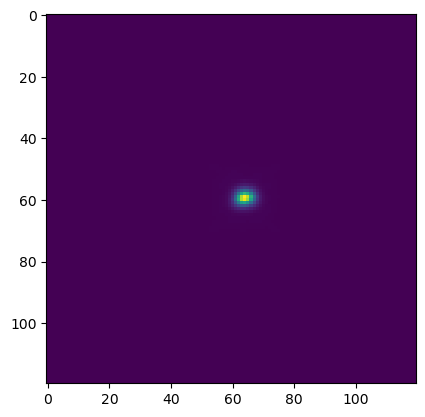

In [17]:
# for_params = prob_model.bij.forward(list(nan_lp_point.T))
phys_model_for = PhysicalModel([epl.EPL(50), shear.Shear()], [sersic.SersicEllipse(),sersic.SersicEllipse(),sersic.SersicEllipse()], [sersic.SersicEllipse(), sersic.SersicEllipse()])
lens_sim_test_for = LensSimulatorTest(phys_model_for, sim_config, bs=1)

bad_sersic = prob_model_test.bij.forward(list(nan_lp_point[None,...].T))[2][1]
bad_sersic['Ie'] = jnp.array([1.0])
# bn = jnp.exp(0.6950 + jnp.log(n_sersic) - 0.1789/n_sersic)
# bad_sersic['n_sersic'] = 0.01

print("bn:", jnp.exp(0.6950 + jnp.log(bad_sersic['n_sersic']) - 0.1789/bad_sersic['n_sersic']))
print(bad_sersic)
# im = lens_sim_test.lstsq_simulate(prob_model_test.bij.forward(list(nan_lp_point.T)))
im = lens_sim_test_for.simulate([[], [], [bad_sersic]])
print("All finite: ", jnp.all(jnp.isfinite(im)))
plt.imshow(im)
plt.show()

(Array(0., dtype=float32), {'Ie': Array([0.], dtype=float32), 'R_sersic': Array([-0.], dtype=float32), 'center_x': Array([-0.], dtype=float32), 'center_y': Array([-0.], dtype=float32), 'e1': Array([0.], dtype=float32), 'e2': Array([0.], dtype=float32), 'n_sersic': Array([0.], dtype=float32)})
n: 0.04900510609149933, bn: 0.0025504871737211943


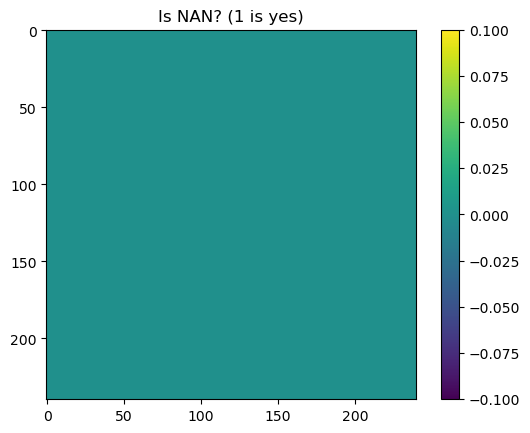

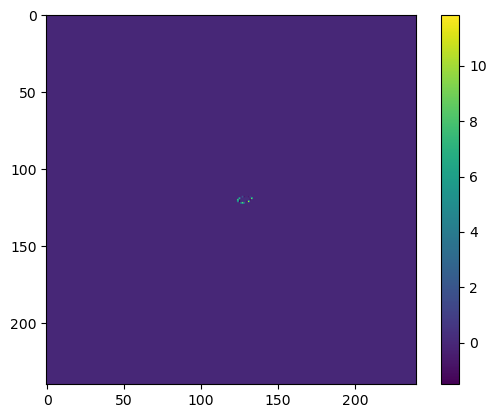

In [49]:
class SersicEllipseTest(sersic.Sersic):
    _name = "SERSIC_ELLIPSE"
    _params = ["R_sersic", "n_sersic", "e1", "e2", "center_x", "center_y"]

    # @functools.partial(jit, static_argnums=(0,))
    def light(self, x, y, R_sersic, n_sersic, e1, e2, center_x, center_y, Ie=None):
        R = self.distance(x, y, center_x, center_y, e1, e2)
        bn = jnp.exp(0.6950 + jnp.log(n_sersic) - 0.1789/n_sersic)

        ratio = R/R_sersic
        is_safe = (1.0 / n_sersic) * jnp.log10(ratio + 1e-10) < 30
        safe_ratio = jnp.where(is_safe, ratio, 0.0)
        
        exponent_factor = bn * (safe_ratio** (1 / n_sersic) - 1.0)        
        ret = jnp.exp(-exponent_factor)

        ret = jnp.where(is_safe, ret, 0.0)
        #* Zero out brighnesses anywhere exponent_factor gets too large
        #* If it is too large, brightness will just be 0, but
        #* it can cause 0*NaN problems in the gradient calculation
        #* e^(-1000) is incredibly small, suppresses everything anyway
        # ret = jnp.where(exponent_factor > 1e3, 0.0, ret) 
        return ret[jnp.newaxis, ...] if self.use_lstsq else (Ie * ret)

    def R(self, x, y, R_sersic, n_sersic, e1, e2, center_x, center_y, Ie=None):
        R = self.distance(x, y, center_x, center_y, e1, e2)
        return R

ser_test = SersicEllipseTest(use_lstsq=True)

def light(sersic_params):
    return jnp.squeeze(ser_test.light(lens_sim_test.img_X,lens_sim_test.img_Y, **sersic_params))

def light_sum(sersic_params):
    return jnp.sum(light(sersic_params))

def light_select(sersic_params):
    return light(sersic_params)[0, 0]

def R(sersic_params):
    return jnp.squeeze(ser_test.R(lens_sim_test.img_X,lens_sim_test.img_Y, **sersic_params))
# jax.vmap(lambda x: jax.value_and_grad(light_sum)(bad_sersic)
# fig, (ax1, ax2) =plt.subplots(1, 2)
bn = lambda n_sersic: jnp.exp(0.6950 + jnp.log(n_sersic) - 0.1789/n_sersic)
bad_n = jnp.squeeze(bad_sersic['n_sersic'])

def ret_point(n_ser, R_ratio):
    return jnp.exp(-bn(n_ser) * (R_ratio ** (1 / n_ser) - 1.0))


print(jax.value_and_grad(light_select)(bad_sersic))
print(f"n: {bad_n}, bn: {bn(bad_n)}")
grads = jax.jacfwd(light)(bad_sersic)

# nan_cutoff = jnp.min(R(bad_sersic)[jnp.isnan(jnp.squeeze(grads['n_sersic']))])
# R_ratio_nan = nan_cutoff/jnp.squeeze(bad_sersic['R_sersic'])

# print(f"NaNs start at R/R_sersic={R_ratio_nan}")

# grad_red_point = jax.grad(ret_point)
# print(ret_point(bad_n, R_ratio_nan*1.5))
# print(grad_red_point(bad_n, R_ratio_nan*1.5))


plt.imshow(jnp.isnan(grads['n_sersic']))
plt.title("Is NAN? (1 is yes)")
plt.colorbar()
plt.show()

plt.imshow(grads['n_sersic'])#, norm='log')
plt.colorbar()
plt.show()
# plt.imshow(light(bad_sersic), norm='log')
# plt.colorbar()
# plt.title("Light")
# plt.show()

In [110]:
bn(bad_n)*R_ratio_nan**(1/bad_n)

Array(7.603662e+32, dtype=float32)

In [19]:
bad_sersic

{'n_sersic': Array([0.04900511], dtype=float32),
 'e2': Array([-0.15304449], dtype=float32),
 'e1': Array([0.32730353], dtype=float32),
 'center_y': Array([0.00481238], dtype=float32),
 'center_x': Array([0.29172197], dtype=float32),
 'R_sersic': Array([0.07392518], dtype=float32),
 'Ie': Array([1.], dtype=float32)}

beta_y: True
beta_x: True
(5, 240, 240, 1)
img: [[ True]
 [ True]
 [ True]
 [ True]
 [ True]]
img post: True
ret: True
ret pooled: True
coeffs: True
ret final: True
All finite:  True


/tmp/ipykernel_748584/1002823520.py:142: DeprecationWarning: The rcond argument for linalg.pinv is deprecated. Please use rtol instead.
  coeffs = (jnp.linalg.pinv(Xt @ X, rcond=1e-6) @ Xt @ Y)[..., 0]


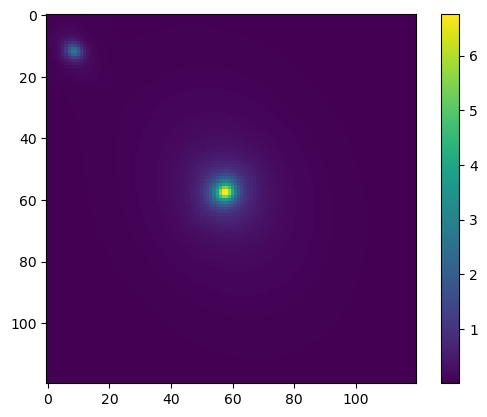

In [26]:
forward_params = prob_model_test.bij.forward(list(nan_lp_point[None,...].T))
err_map = jnp.sqrt(
    background_rms ** 2 + jnp.clip(jnp.array(observed_img), 0, jnp.inf) / exp_time
)
im_sim = lens_sim_test.lstsq_simulate(forward_params, jnp.array(observed_img), err_map, no_deflection=True)[0]
print("All finite: ", jnp.all(jnp.isfinite(im_sim)))
plt.imshow(im_sim)
plt.colorbar()
plt.show()

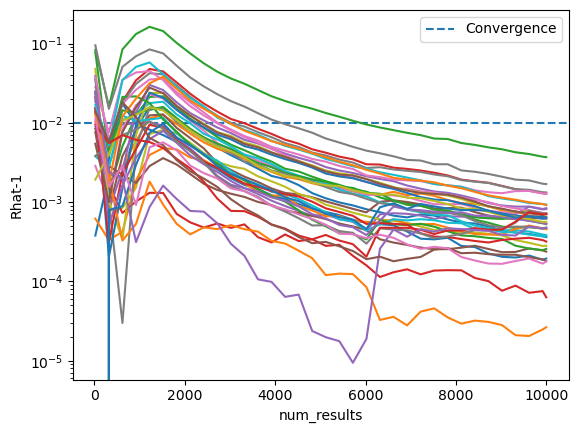

In [221]:
hmc_samp = hmc_samples[:16]
sample_length = list(range(20, hmc_samp.shape[1], 300)) + [hmc_samp.shape[1]]
rhats = -np.ones((len(sample_length), multi_chain_samples.shape[-1]))
for i, l in enumerate(sample_length):
    rhats[i] = blackjax.diagnostics.potential_scale_reduction(hmc_samp[:, :l, :], chain_axis=0, sample_axis=1)
plt.axhline(1e-2, linestyle='--', label='Convergence')
plt.plot(sample_length, rhats-1)
plt.yscale('log')
plt.ylabel("Rhat-1")
plt.xlabel("num_results")
plt.legend()
plt.show()

In [222]:
hmc_ESS = blackjax.diagnostics.effective_sample_size(hmc_samples[:16], chain_axis=0, sample_axis=1)
np.min(hmc_ESS)

Array(1770.3047, dtype=float32)

In [48]:
print(f"MAP Log Prob: {log_prob(jnp.squeeze(map_best))}")
print(f"qz Mean Log Prob: {log_prob(qz.loc)}")
print(f"HMC Median Log Prob: {log_prob(jnp.median(multi_chain_samples, axis=(0, 1)))}")

MAP Log Prob: 45837.1484375
qz Mean Log Prob: 45837.1484375
HMC Median Log Prob: 45925.47265625


2026-03-03 08:35:04.383156: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.


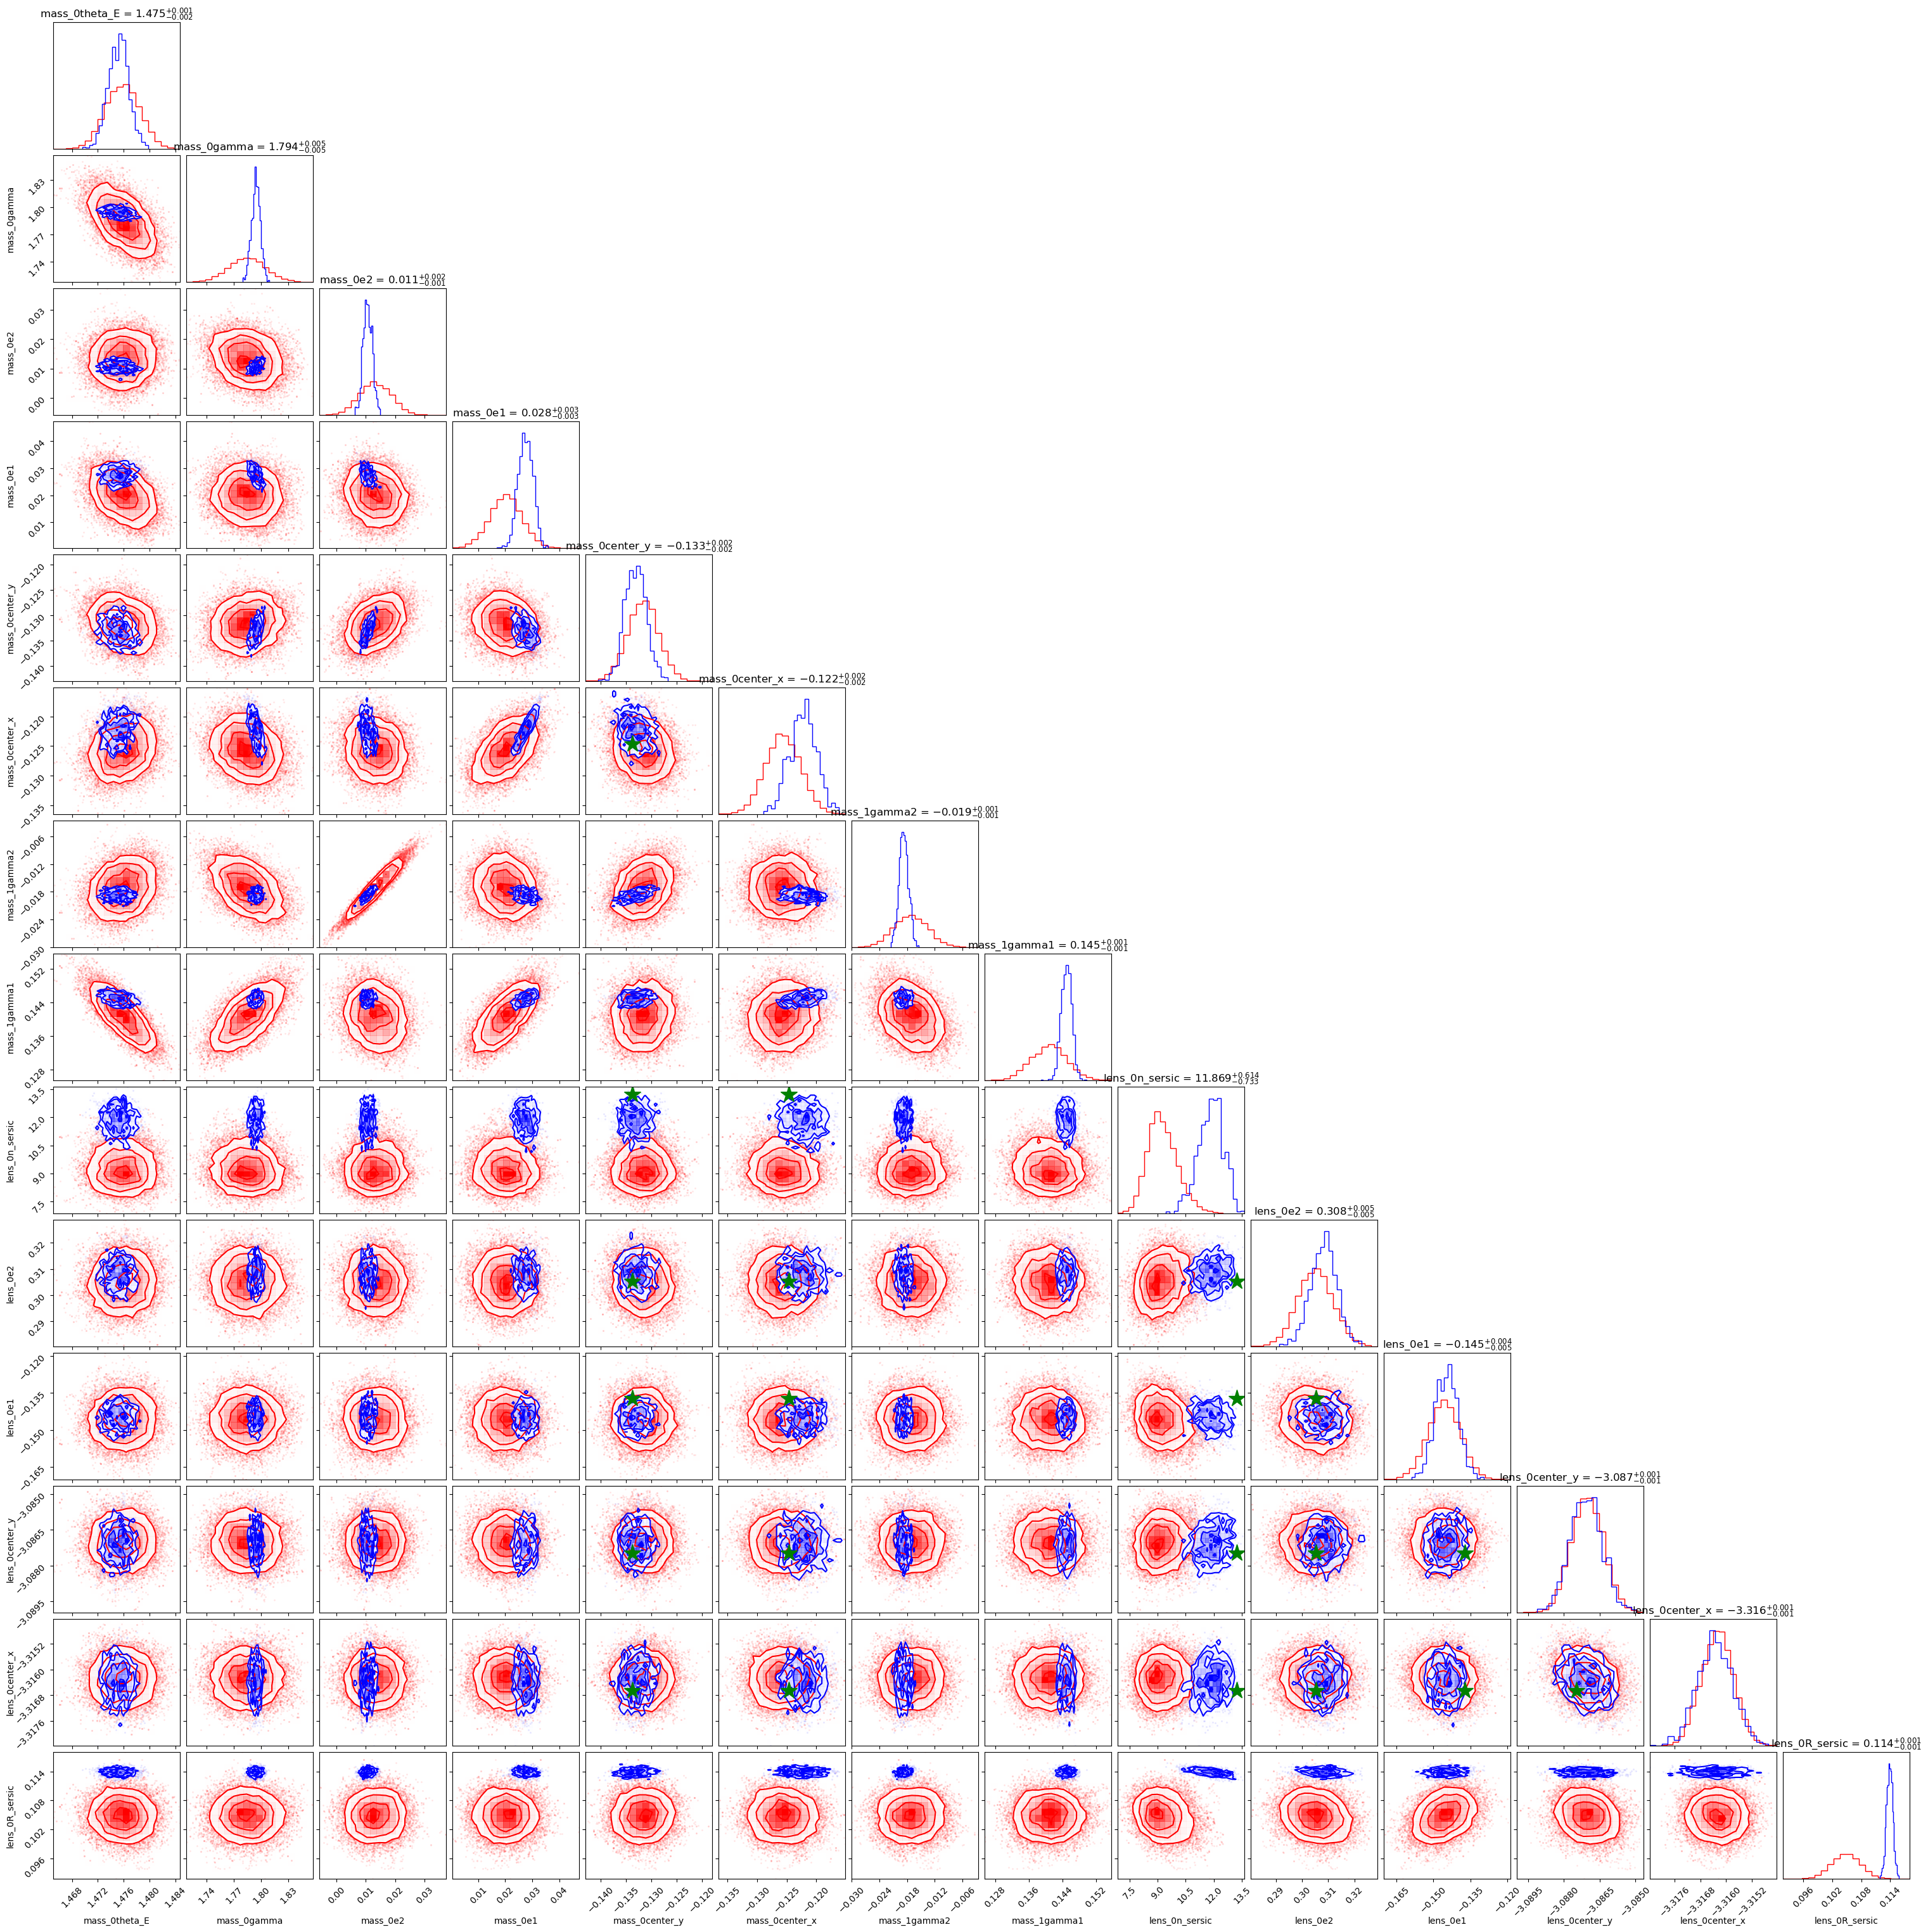

In [22]:
samples = multi_chain_samples
samples = samples.reshape(-1, samples.shape[-1]) #samples_mclmc 
MCMC_x = prob_model.bij.forward(list(samples.T))

# HMC_x = prob_model.bij.forward(list(hmc_samples.reshape(-1, hmc_samples.shape[-1]).T))

# adapt_cov = blackjax_mclmc_sampler_params.inverse_mass_matrix
# adapt_qz = tfd.MultivariateNormalFullCovariance(loc=jnp.mean(samples, axis=0), covariance_matrix=adapt_cov)
# adapt_qz_samples = adapt_qz.sample((1000,), run_key)
# adapt_qz_x = prob_model.bij.forward(list(adapt_qz_samples.T))

svi_samples = qz.sample((1000,), run_key)
svi_x = prob_model.bij.forward(list(svi_samples.T))

map_x = prob_model.bij.forward(list(map_best.T))

# HMC_1chain_x = prob_model.bij.forward(list(results['HMC'].HMC_samples_z[0, 11, -40000:].T))

plot_params = cornerplot_labels(MCMC_x)[:14] #! Only plot some params for speed. CHANGE LATER

# n_samp = HMC_x[0][0]['e1'].shape[0]
# rand_idx = np.random.choice(np.arange(n_samp), size=(20000,), replace=False)

# fig = cornerplot_posterior(jax.tree.map(lambda x: x[rand_idx], HMC_x), color='black',plot_params=plot_params)

n_samp_MCMC = MCMC_x[0][0]['e1'].shape[0]
rand_idx_MCMC = np.random.choice(np.arange(n_samp_MCMC), size=(20000,), replace=True)
fig = cornerplot_posterior(jax.tree.map(lambda x: x[rand_idx_MCMC], MCMC_x), color='red',plot_params=plot_params)#, fig=fig)

cornerplot_posterior(svi_x, color='blue', plot_params=plot_params, fig=fig, overplots=map_x, overplot_color='green')
# cornerplot_posterior(adapt_qz_x, plot_params=plot_params, fig=fig, color='purple')
# cornerplot_posterior(mclmc_results_100sys.HMC_samples, fig=fig, color='purple', plot_params=plot_params)
# cornerplot_posterior(HMC_1chain_x, fig=fig, color='green', plot_params=plot_params)
plt.show()

In [22]:
def bridge_sampler(rng_key, samples, log_posterior_fn, n_iter=50):
    """
    Estimates the log-marginal likelihood using the Meng-Wong bridge sampler.
    
    Args:
        rng_key: JAX random key.
        samples: MCMC samples of shape (n_samples, n_dim).
        log_posterior_fn: Function mapping (theta) -> log_posterior(theta).
        n_iter: Number of iterations for the Meng-Wong algorithm.
    """
    n_samples, n_dim = samples.shape
    
    # 1. Fit a Gaussian proposal to the MCMC samples
    mu = jnp.mean(samples, axis=0)
    cov = jnp.cov(samples, rowvar=False)
    proposal = tfd.MultivariateNormalFullCovariance(loc=mu, covariance_matrix=cov)
    
    # 2. Draw 'fake' samples from the proposal
    prop_key, _ = jax.random.split(rng_key)
    gen_samples = proposal.sample(n_samples, seed=prop_key)
    
    # 3. Evaluate log-densities (vmap for speed)
    # l1: log-posterior of MCMC samples
    # l2: log-posterior of Gen samples
    l1 = jax.vmap(log_posterior_fn)(samples)
    l2 = jax.vmap(log_posterior_fn)(gen_samples)
    # max_lp = jnp.max(l1)
    # l1 -= max_lp
    # l2 -= max_lp

    # print(l1)
    # print(l2)
    
    # q1: log-proposal of MCMC samples
    # q2: log-proposal of Gen samples
    q1 = proposal.log_prob(samples)
    q2 = proposal.log_prob(gen_samples)
    # print(q1)
    # print(q2)
    
    # 4. Iterative Meng-Wong Algorithm
    # Initial guess for the marginal likelihood (r = Z_posterior / Z_proposal)
    # Since Z_proposal = 1 (normalized), r is the evidence Z.
    log_r_guess = jnp.log(1/n_samples) + jax.nn.logsumexp(l2-q2)
    print(log_r_guess)
    log_r = log_r_guess

    
    h = []
    s1 = 0.5 # Proportion of samples from posterior (assuming n1 == n2)
    s2 = 0.5 # Proportion of samples from proposal
    
    for _ in range(n_iter):
        # We want to compute the update: 
        # r_new = (sum(q2 / (s1*q2 + s2*r*g2))) / (sum(g1 / (s1*q1 + s2*r*g1)))
        
        # Let's define the terms for the numerator and denominator in log-space
        # Numerator term: log( q(theta_gen) / (s1*q(theta_gen) + s2*r*g(theta_gen)) )
        l_num = l2 - jnp.logaddexp(jnp.log(s1) + l2, jnp.log(s2) + log_r + q2)
        
        # Denominator term: log( g(theta_mcmc) / (s1*q(theta_mcmc) + s2*r*g(theta_mcmc)) )
        l_den = q1 - jnp.logaddexp(jnp.log(s1) + l1, jnp.log(s2) + log_r + q1)
        
        # Update log_r
        log_r_new = jax.nn.logsumexp(l_num) - jax.nn.logsumexp(l_den)
        
        # For stability, we can track the delta or use a small dampening factor if needed
        log_r = log_r_new
        h.append(log_r)

    return log_r, h


In [27]:
smp = multi_chain_samples.reshape(-1, dim)
idxes = np.random.choice(smp.shape[0], size=(200,), replace=False)
r, hist = bridge_sampler(jax.random.key(0), smp[idxes], log_prob,n_iter=50)

2026-02-24 19:14:26.574829: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-02-24 19:14:28.370841: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-02-24 19:14:32.222434: E external/xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng28{k2=3,k3=0} for conv %cudnn-conv.1 = (f32[200,4,240,240]{3,2,1,0}, u8[0]{0}) custom-call(%bitcast.434, %constant.261), window={size=53x53 pad=26_26x26_26}, dim_labels=bf01_oi01->bf01, feature_group_count=4, custom_call_target="__cudnn$convForward", metadata={op_name="j

44275.785


In [28]:
print(r)

44271.53


In [25]:
#log(r) for two-source model: 44271.53 (200 smp) (or 44272.633 for 1000 samples)
#log(r) for two-source model: 45779.387 (200 smp) (or 45779.97 for 1000 samples)
#log(r) for three-source model: 45923.23 (200 smp) (or 45925.473 for 1000 samples)

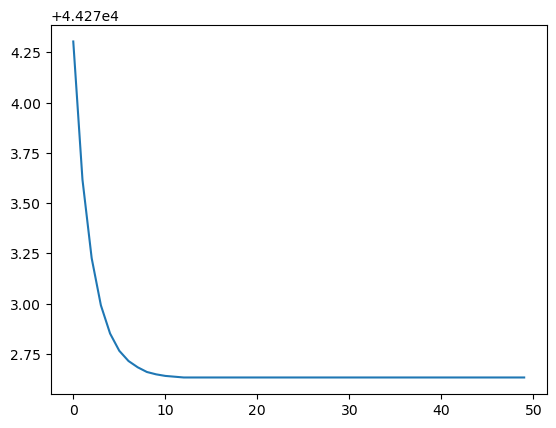

In [26]:
plt.plot(hist)

In [86]:
egval, egvec = jnp.linalg.eig(adapt_cov)

In [87]:
egval

Array([2.10453421e-02+0.j, 2.03757603e-02+0.j, 8.43444094e-03+0.j,
       5.04266704e-03+0.j, 4.23819711e-03+0.j, 2.62749707e-03+0.j,
       9.91778914e-04+0.j, 8.77709943e-04+0.j, 7.37061317e-04+0.j,
       6.04708097e-04+0.j, 5.54775586e-04+0.j, 4.97803849e-04+0.j,
       3.41999956e-04+0.j, 3.10357078e-04+0.j, 2.73336685e-04+0.j,
       2.16185072e-04+0.j, 1.84443663e-04+0.j, 9.89721520e-05+0.j,
       8.58387502e-05+0.j, 8.16472239e-05+0.j, 4.62227545e-05+0.j,
       3.39954167e-05+0.j, 1.24988046e-05+0.j, 8.32604837e-06+0.j,
       6.52492145e-06+0.j, 3.85340718e-06+0.j, 3.59795649e-06+0.j,
       2.05623428e-06+0.j, 1.16555145e-06+0.j, 6.85786290e-07+0.j,
       5.90399509e-07+0.j, 5.32548370e-07+0.j, 1.02394054e-07+0.j,
       1.90983030e-07+0.j, 2.85903923e-07+0.j, 2.66462905e-07+0.j,
       2.23376773e-07+0.j, 2.37112062e-07+0.j], dtype=complex64)

In [88]:
adapt_qz.covariance()

Array([[ 5.3439871e-06, -7.3909723e-07,  3.7002261e-05, ...,
         1.9594620e-05,  5.4189441e-06, -1.4920835e-05],
       [-7.3909723e-07,  4.4642479e-06, -1.2276083e-05, ...,
         1.3272127e-05, -2.3487777e-05, -2.0977448e-05],
       [ 3.7002261e-05, -1.2276083e-05,  3.4668474e-04, ...,
         9.9791643e-05,  8.5930624e-05, -6.7903835e-05],
       ...,
       [ 1.9594620e-05,  1.3272127e-05,  9.9791643e-05, ...,
         8.2266098e-03, -1.0099047e-03, -1.2249177e-03],
       [ 5.4189441e-06, -2.3487777e-05,  8.5930624e-05, ...,
        -1.0099047e-03,  5.3639109e-03,  1.9840915e-03],
       [-1.4920835e-05, -2.0977448e-05, -6.7903835e-05, ...,
        -1.2249177e-03,  1.9840915e-03,  2.0043708e-02]], dtype=float32)